In [1]:
import sys

In [2]:
sys.path.append('../')

In [3]:
import my_functions 

# SMOTE-N

In [4]:
from sklearn.datasets import make_blobs
from imblearn.over_sampling import SMOTEN

In [5]:
import imblearn.metrics

In [7]:
dir(imblearn.metrics.pairwise)

['BaseEstimator',
 'StrOptions',
 'ValueDifferenceMetric',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_fit_context',
 'check_array',
 'check_consistent_length',
 'check_is_fitted',
 'distance_matrix',
 'np',
 'numbers',
 'unique_labels',
 'validate_data']

In [8]:
from imblearn.metrics.pairwise import ValueDifferenceMetric

# Distance between values

In [13]:
np.array('green' * 10)

array('greengreengreengreengreengreengreengreengreengreen', dtype='<U50')

In [14]:
np.array(['green'] * 10) 

array(['green', 'green', 'green', 'green', 'green', 'green', 'green',
       'green', 'green', 'green'], dtype='<U5')

In [15]:
data1 = ['green']*10

In [16]:
data2 = ['red']*10

In [17]:
data3 = ['blue']*10

In [19]:
np.array(data1 + data2 + data3).shape

(30,)

In [20]:
np.array(data1 + data2 + data3).reshape(-1,1).shape

(30, 1)

In [21]:
X = np.array(data1 + data2 + data3).reshape(-1,1)
y = [1] * 8 + [0] * 5 + [1] * 7 +[0] * 9 + [1]

In [24]:
len(X), len(y)

(30, 30)

In [25]:
import sklearn.preprocessing

In [26]:
for item in dir(sklearn.preprocessing):
    if 'coder' in item:
        print(item)

LabelEncoder
OneHotEncoder
OrdinalEncoder
TargetEncoder
_encoders
_target_encoder
_target_encoder_fast


In [27]:
from sklearn.preprocessing import OrdinalEncoder

In [30]:
?OrdinalEncoder

Init signature:
OrdinalEncoder(
    *,
    categories='auto',
    dtype=<class 'numpy.float64'>,
    handle_unknown='error',
    unknown_value=None,
    encoded_missing_value=nan,
    min_frequency=None,
    max_categories=None,
)
Docstring:     
Encode categorical features as an integer array.

The input to this transformer should be an array-like of integers or
strings, denoting the values taken on by categorical (discrete) features.
The features are converted to ordinal integers. This results in
a single column of integers (0 to n_categories - 1) per feature.

Read more in the :ref:`User Guide <preprocessing_categorical_features>`.
For a comparison of different encoders, refer to:
:ref:`sphx_glr_auto_examples_preprocessing_plot_target_encoder.py`.

.. versionadded:: 0.20

Parameters
----------
categories : 'auto' or a list of array-like, default='auto'
    Categories (unique values) per feature:

    - 'auto' : Determine categories automatically from the training data.
    - list : 

In [32]:
encoder = OrdinalEncoder(
    dtype=np.int32
)

In [33]:
X_enc = encoder.fit_transform(X)

In [38]:
X_enc.shape, X.shape

((30, 1), (30, 1))

In [43]:
pd.concat([pd.Series(X.flatten()), pd.Series(X_enc.flatten())], axis=1)

,0,1
0,green,1
1,green,1
2,green,1
3,green,1
4,green,1
5,green,1
6,green,1
7,green,1
8,green,1
9,green,1


In [47]:
dir(imblearn.metrics.pairwise)

['BaseEstimator',
 'StrOptions',
 'ValueDifferenceMetric',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_fit_context',
 'check_array',
 'check_consistent_length',
 'check_is_fitted',
 'distance_matrix',
 'np',
 'numbers',
 'unique_labels',
 'validate_data']

In [48]:
from imblearn.metrics.pairwise import ValueDifferenceMetric

In [50]:
?ValueDifferenceMetric

Init signature: ValueDifferenceMetric(*, n_categories='auto', k=1, r=2)
Docstring:     
Class implementing the Value Difference Metric.

This metric computes the distance between samples containing only
categorical features. The distance between feature values of two samples is
defined as:

.. math::
   \delta(x, y) = \sum_{c=1}^{C} |p(c|x_{f}) - p(c|y_{f})|^{k} \ ,

where :math:`x` and :math:`y` are two samples and :math:`f` a given
feature, :math:`C` is the number of classes, :math:`p(c|x_{f})` is the
conditional probability that the output class is :math:`c` given that
the feature value :math:`f` has the value :math:`x` and :math:`k` an
exponent usually defined to 1 or 2.

The distance for the feature vectors :math:`X` and :math:`Y` is
subsequently defined as:

.. math::
   \Delta(X, Y) = \sum_{f=1}^{F} \delta(X_{f}, Y_{f})^{r} \ ,

where :math:`F` is the number of feature and :math:`r` an exponent usually
defined equal to 1 or 2.

The definition of this distance was propoed in [1]_

In [53]:
vdm = ValueDifferenceMetric(r=1).fit(X_enc, y)

In [54]:
dir(vdm)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_validate_data',
 '_validate_params',
 'fit',
 'get_metadata_routing',
 'get_params',
 'k',
 'n_categories',
 'n_categories_',
 'n_features_in_',
 'pairwise',
 'proba_

In [55]:
for item in dir(vdm):
    if 'proba' in item:
        print(item)

proba_per_class_


In [62]:
#conditional probability of the categories
vdm.proba_per_class_

[array([[0.9, 0.1],
        [0.2, 0.8],
        [0.3, 0.7]])]

In [61]:
vdm2 = ValueDifferenceMetric(r=2).fit(X_enc, y)
vdm2.proba_per_class_

[array([[0.9, 0.1],
        [0.2, 0.8],
        [0.3, 0.7]])]

In [63]:
dir(encoder)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_check_X',
 '_check_feature_names',
 '_check_infrequent_enabled',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_fit',
 '_fit_infrequent_category_mapping',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_identify_infrequent',
 '_infrequent_enabled',
 '_map_infrequent_categories',
 '_missing_indices',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 

In [64]:
encoder.categories

'auto'

In [65]:
encoder.categories_

[array(['blue', 'green', 'red'], dtype='<U5')]

In [68]:
X_test = np.array(['red', 'green', 'blue']).reshape(-1,1)


In [70]:
X_test_enc = encoder.transform(X_test)

In [71]:
?vdm.pairwise

Signature: vdm.pairwise(X, Y=None)
Docstring:
Compute the VDM distance pairwise.

Parameters
----------
X : ndarray of shape (n_samples, n_features), dtype=np.int32
    The input data. The data are expected to be encoded with a
    :class:`~sklearn.preprocessing.OrdinalEncoder`.

Y : ndarray of shape (n_samples, n_features), dtype=np.int32
    The input data. The data are expected to be encoded with a
    :class:`~sklearn.preprocessing.OrdinalEncoder`.

Returns
-------
distance_matrix : ndarray of shape (n_samples, n_samples)
    The VDM pairwise distance.
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/imblearn/metrics/pairwise.py
Type:      method

In [ ]:
#Distance matrix
vdm.pairwise(X_test_enc)

array([[0. , 0.2, 1.2],
       [0.2, 0. , 1.4],
       [1.2, 1.4, 0. ]])

# Distance between vectors

In [92]:
data1 = pd.Series(np.array(['green']*10 + ['red']*10 + ['blue']*10))

In [93]:
data2 = pd.Series(np.array(["used"] + ["new"] + ["used"] + ["new"] * 2 +
                       ["used"] * 2 + ["new"] * 3 + ["used"] * 4 + 
                       ["new"] * 6 + ["used"] * 6 + ["new"] * 4))

In [ ]:
#The extra comma at the very end, somehow turn a panda series to a tupe
#Make sure to watch those extra characters
data3 = pd.Series(np.array(["used"] + ["new"] + ["used"] + ["new"] * 2 +
                       ["used"] * 2 + ["new"] * 3 + ["used"] * 4 + 
                       ["new"] * 6 + ["used"] * 6 + ["new"] * 4)),

In [95]:
data4 = pd.Series(np.array(["used"] + ["new"] + ["used"] + ["new"] * 2 +
                       ["used"] * 2 + ["new"] * 3 + ["used"] * 4 + 
                       ["new"] * 6 + ["used"] * 6 + ["new"] * 4)),

In [96]:
type(data1), type(data2), type(data3), type(data4)

(pandas.core.series.Series, pandas.core.series.Series, tuple, tuple)

In [98]:
X = pd.concat([data1, data2], axis=1)

X.columns = ['colour', 'condition']
X.head()


,colour,condition
0,green,used
1,green,new
2,green,used
3,green,new
4,green,new


In [99]:
# target
y = [1] * 8 + [0] * 5 + [1] * 7 + [0] * 9 + [1]

In [100]:
type(y)

list

In [101]:
?OrdinalEncoder

Init signature:
OrdinalEncoder(
    *,
    categories='auto',
    dtype=<class 'numpy.float64'>,
    handle_unknown='error',
    unknown_value=None,
    encoded_missing_value=nan,
    min_frequency=None,
    max_categories=None,
)
Docstring:     
Encode categorical features as an integer array.

The input to this transformer should be an array-like of integers or
strings, denoting the values taken on by categorical (discrete) features.
The features are converted to ordinal integers. This results in
a single column of integers (0 to n_categories - 1) per feature.

Read more in the :ref:`User Guide <preprocessing_categorical_features>`.
For a comparison of different encoders, refer to:
:ref:`sphx_glr_auto_examples_preprocessing_plot_target_encoder.py`.

.. versionadded:: 0.20

Parameters
----------
categories : 'auto' or a list of array-like, default='auto'
    Categories (unique values) per feature:

    - 'auto' : Determine categories automatically from the training data.
    - list : 

In [103]:
?encoder

Type:        OrdinalEncoder
String form: OrdinalEncoder(dtype=<class 'numpy.int32'>)
File:        ~/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py
Docstring:  
Encode categorical features as an integer array.

The input to this transformer should be an array-like of integers or
strings, denoting the values taken on by categorical (discrete) features.
The features are converted to ordinal integers. This results in
a single column of integers (0 to n_categories - 1) per feature.

Read more in the :ref:`User Guide <preprocessing_categorical_features>`.
For a comparison of different encoders, refer to:
:ref:`sphx_glr_auto_examples_preprocessing_plot_target_encoder.py`.

.. versionadded:: 0.20

Parameters
----------
categories : 'auto' or a list of array-like, default='auto'
    Categories (unique values) per feature:

    - 'auto' : Determine categories automatically from the training data.
    - list : ``categories[i]`` h

In [102]:
encoder = OrdinalEncoder(
    dtype=np.int32

)

X_enc = encoder.fit_transform(X)

In [106]:
X.head()

,colour,condition
0,green,used
1,green,new
2,green,used
3,green,new
4,green,new


In [105]:
X_enc[:5]

array([[1, 1],
       [1, 0],
       [1, 1],
       [1, 0],
       [1, 0]], dtype=int32)

In [107]:
for item in dir(encoder):
    if 'categ' in item:
        print(item)

_fit_infrequent_category_mapping
_map_infrequent_categories
categories
categories_
infrequent_categories_
max_categories


In [108]:
encoder.categories_

[array(['blue', 'green', 'red'], dtype=object),
 array(['new', 'used'], dtype=object)]

In [111]:
for item in dir(imblearn.metrics.pairwise):
    if 'alue' in item:
        print(item)

ValueDifferenceMetric


In [112]:
?ValueDifferenceMetric

Init signature: ValueDifferenceMetric(*, n_categories='auto', k=1, r=2)
Docstring:     
Class implementing the Value Difference Metric.

This metric computes the distance between samples containing only
categorical features. The distance between feature values of two samples is
defined as:

.. math::
   \delta(x, y) = \sum_{c=1}^{C} |p(c|x_{f}) - p(c|y_{f})|^{k} \ ,

where :math:`x` and :math:`y` are two samples and :math:`f` a given
feature, :math:`C` is the number of classes, :math:`p(c|x_{f})` is the
conditional probability that the output class is :math:`c` given that
the feature value :math:`f` has the value :math:`x` and :math:`k` an
exponent usually defined to 1 or 2.

The distance for the feature vectors :math:`X` and :math:`Y` is
subsequently defined as:

.. math::
   \Delta(X, Y) = \sum_{f=1}^{F} \delta(X_{f}, Y_{f})^{r} \ ,

where :math:`F` is the number of feature and :math:`r` an exponent usually
defined equal to 1 or 2.

The definition of this distance was propoed in [1]_

In [113]:
vdm = ValueDifferenceMetric(n_categories='auto', r=2).fit(X_enc, y)

In [114]:
dir(vdm)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_validate_data',
 '_validate_params',
 'fit',
 'get_metadata_routing',
 'get_params',
 'k',
 'n_categories',
 'n_categories_',
 'n_features_in_',
 'pairwise',
 'proba_

In [117]:
encoder.categories_

[array(['blue', 'green', 'red'], dtype=object),
 array(['new', 'used'], dtype=object)]

In [116]:
vdm.proba_per_class_

[array([[0.9, 0.1],
        [0.2, 0.8],
        [0.3, 0.7]]),
 array([[0.3125    , 0.6875    ],
        [0.64285714, 0.35714286]])]

In [ ]:
X_test = pd.concat([])

In [118]:
# Now we create some new data with some vector
# combinations of the 2 variables

X_test = pd.concat([
    pd.Series(np.array(["green"]+["green"]+["red"]+["red"])),
    pd.Series(np.array(["used"] + ["new"] + ["used"] + ["new"])),
], axis=1)


X_test.columns = ['colour', 'condition']

X_test

,colour,condition
0,green,used
1,green,new
2,red,used
3,red,new


In [120]:
X_test_enc = encoder.transform(X_test)

In [121]:
?vdm.pairwise

Signature: vdm.pairwise(X, Y=None)
Docstring:
Compute the VDM distance pairwise.

Parameters
----------
X : ndarray of shape (n_samples, n_features), dtype=np.int32
    The input data. The data are expected to be encoded with a
    :class:`~sklearn.preprocessing.OrdinalEncoder`.

Y : ndarray of shape (n_samples, n_features), dtype=np.int32
    The input data. The data are expected to be encoded with a
    :class:`~sklearn.preprocessing.OrdinalEncoder`.

Returns
-------
distance_matrix : ndarray of shape (n_samples, n_samples)
    The VDM pairwise distance.
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/.venv/lib/python3.10/site-packages/imblearn/metrics/pairwise.py
Type:      method

In [ ]:
#Distance metric, using the manhattan distance metric between the conditional probabilities
vdm.pairwise(X_test_enc)

array([[0.        , 0.43654337, 0.04      , 0.47654337],
       [0.43654337, 0.        , 0.47654337, 0.04      ],
       [0.04      , 0.47654337, 0.        , 0.43654337],
       [0.47654337, 0.04      , 0.43654337, 0.        ]])

# SMOTE-N

In [123]:
rng = np.random.RandomState(42)
num_samples=1600

In [134]:
data1 = pd.Series(rng.choice(['Blue', 'Green', 'Red'], size=num_samples).astype(object))

In [135]:
data2 = pd.Series(rng.choice(['New', 'User'], size=num_samples).astype(object))

In [136]:
data3 = pd.Series(rng.choice(['Classic', 'Luxus', 'Smart'], size=num_samples).astype(object))

In [139]:
X = pd.concat([data1, data2, data3],axis=1)
X.columns = ['Colour', 'Condition', 'Model']

X.head()

,Colour,Condition,Model
0,Red,User,Luxus
1,Red,User,Luxus
2,Blue,User,Smart
3,Blue,User,Luxus
4,Blue,New,Luxus


In [149]:
?rng.binomial

Signature: rng.binomial(n, p, size=None)
Docstring:
binomial(n, p, size=None)

Draw samples from a binomial distribution.

Samples are drawn from a binomial distribution with specified
parameters, n trials and p probability of success where
n an integer >= 0 and p is in the interval [0,1]. (n may be
input as a float, but it is truncated to an integer in use)

.. note::
    New code should use the `~numpy.random.Generator.binomial`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

Parameters
----------
n : int or array_like of ints
    Parameter of the distribution, >= 0. Floats are also accepted,
    but they will be truncated to integers.
p : float or array_like of floats
    Parameter of the distribution, >= 0 and <=1.
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn.  If size is ``None`` (default),
    a single value is returned if ``n

In [153]:
y = pd.Series(rng.binomial(p=0.1, n=1, size=num_samples))
y.value_counts()

0    1434
1     166
Name: count, dtype: int64

In [157]:
dir(y.plot)

['__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_accessors',
 '_all_kinds',
 '_common_kinds',
 '_constructor',
 '_dataframe_kinds',
 '_dir_additions',
 '_dir_deletions',
 '_get_call_args',
 '_hidden_attrs',
 '_kind_aliases',
 '_parent',
 '_reset_cache',
 '_series_kinds',
 'area',
 'bar',
 'barh',
 'box',
 'density',
 'hexbin',
 'hist',
 'kde',
 'line',
 'pie',
 'scatter']

<Axes: ylabel='Density'>

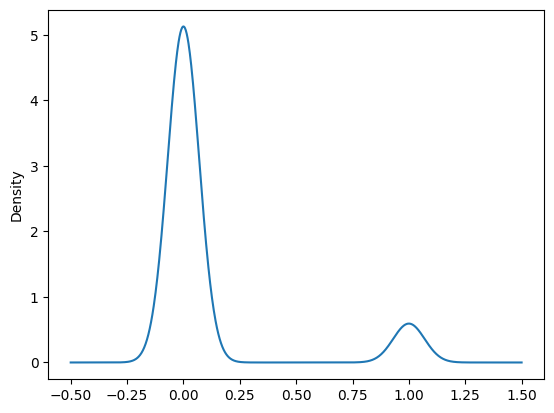

In [158]:
y.plot.density()

<Axes: ylabel='Frequency'>

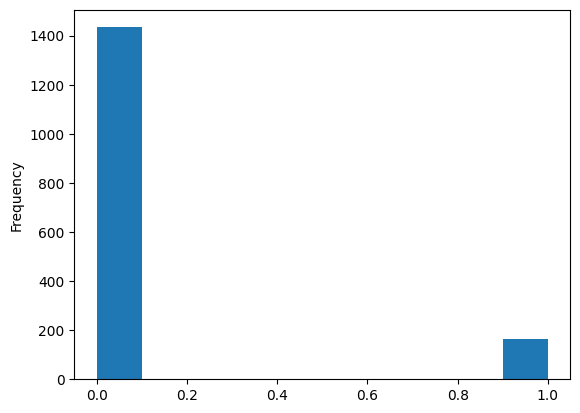

In [160]:
y.plot.hist()

In [141]:
for var in X.columns:
    print(X[var].value_counts(normalize=True))
    print()

Colour
Red     0.3488
Blue    0.3406
Green   0.3106
Name: proportion, dtype: float64

Condition
User   0.5194
New    0.4806
Name: proportion, dtype: float64

Model
Luxus     0.3475
Classic   0.3281
Smart     0.3244
Name: proportion, dtype: float64



In [143]:
for item in dir(imblearn):
    if 'over' in item:
        print(item)

over_sampling


In [144]:
from imblearn.over_sampling import SMOTEN

In [145]:
?SMOTEN

Init signature:
SMOTEN(
    categorical_encoder=None,
    *,
    sampling_strategy='auto',
    random_state=None,
    k_neighbors=5,
)
Docstring:     
Synthetic Minority Over-sampling Technique for Nominal.

This method is referred as SMOTEN in [1]_. It expects that the data to
resample are only made of categorical features.

Read more in the :ref:`User Guide <smote_adasyn>`.

.. versionadded:: 0.8

Parameters
----------
categorical_encoder : estimator, default=None
    Ordinal encoder used to encode the categorical features. If `None`, a
    :class:`~sklearn.preprocessing.OrdinalEncoder` is used with default parameters.

sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm

In [161]:
X.shape, y.shape

((1600, 3), (1600,))

In [162]:
sampler = SMOTEN(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=5,
)

X_res, y_res = sampler.fit_resample(X,y)


In [163]:
y.value_counts(), y_res.value_counts()

(0    1434
 1     166
 Name: count, dtype: int64,
 0    1434
 1    1434
 Name: count, dtype: int64)